# CASO PRÁCTICO: DATAEXPERT
## Fundamentos y Algoritmia para Inteligencia Artificial
Dataset: Seeds (UCI Machine Learning Repository) - 210 semillas de trigo de 3 variedades (Kama, Rosa, Canadian), 7 características geométricas y la variable Class.

## 1. IMPORTACIÓN DE LIBRERÍAS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split #dividir la data en train y test
from sklearn.preprocessing import StandardScaler #escala los datos
from sklearn.metrics import accuracy_score, classification_report #metricas para clasificacion
#COMPARAR LOS SIGUIENTES MODELOS
from sklearn.tree import DecisionTreeClassifier #(ARBOL DE DECISION)
from sklearn.neighbors import KNeighborsClassifier #(K VECINOS CERCANOS)

## 2. CARGA Y EXPLORACIÓN DEL DATASET CON PANDAS

In [ ]:
caracteristicas_df = ['Area', 'Perimeter', 'Compactness', 'Length', 'Width', 'Asymmetry', 'Groove', 'Class']
seeds = pd.read_csv('seeds_dataset.csv')
seeds.head()

,Area,Perimeter,Compactness,Length,Width,Asymmetry,Groove,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [ ]:
print('---Analisis exploratorio del dataset---')
print(seeds.shape) #FILAS Y COLUMNAS
print(seeds.columns) #NOMBRES DE LAS COLUMNAS
seeds.info()

---Analisis exploratorio del dataset---
(210, 8)
Index(['Area', 'Perimeter', 'Compactness', 'Length', 'Width', 'Asymmetry',
       'Groove', 'Class'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         210 non-null    float64
 1   Perimeter    210 non-null    float64
 2   Compactness  210 non-null    float64
 3   Length       210 non-null    float64
 4   Width        210 non-null    float64
 5   Asymmetry    210 non-null    float64
 6   Groove       210 non-null    float64
 7   Class        210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [ ]:
seeds.describe()

,Area,Perimeter,Compactness,Length,Width,Asymmetry,Groove,Class
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [ ]:
#IDENTIFICAMOS LAS 7 CARACTERISTICAS (TODAS LAS COLUMNAS MENOS CLASS)
caracteristicas= seeds.columns.drop('Class')
print(caracteristicas)
print(len(caracteristicas))

Index(['Area', 'Perimeter', 'Compactness', 'Length', 'Width', 'Asymmetry',
       'Groove'],
      dtype='str')
7


In [ ]:
#VERIFICAMOS VALORES NULOS
print(seeds.isnull().sum())
print('Total de nulos:', seeds.isnull().sum().sum())

Area           0
Perimeter      0
Compactness    0
Length         0
Width          0
Asymmetry      0
Groove         0
Class          0
dtype: int64
Total de nulos: 0


In [ ]:
#CANTIDAD DE MUESTRAS POR VARIEDAD (1: Kama, 2: Rosa, 3: Canadian)
print(seeds['Class'].value_counts())

Class
1    70
2    70
3    70
Name: count, dtype: int64


## 3. SEPARACIÓN DE X e y Y NORMALIZACIÓN (StandardScaler)

In [ ]:
x= seeds.drop('Class', axis=1) #CARACTERISTICAS PREDICTORAS
y= seeds['Class'] #VARIABLE A PREDECIR
print(x.shape)
print(y.shape)

(210, 7)
(210,)


In [ ]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=42)

In [ ]:
#Normalizamos los datos (X)
scaler= StandardScaler()
x_train= scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)

In [ ]:
#COMPROBAMOS: MEDIA CERCANA A 0 Y DESVIACION ESTANDAR CERCANA A 1
print(np.round(x_train.mean(axis=0), 4))
print(np.round(x_train.std(axis=0), 4))

[ 0.  0. -0.  0.  0. -0.  0.]
[1. 1. 1. 1. 1. 1. 1.]


## 4. ÁLGEBRA LINEAL CON NUMPY

In [ ]:
#VECTORES: LAS DOS PRIMERAS SEMILLAS (7 CARACTERISTICAS CADA UNA)
v1= x.iloc[0].values
v2= x.iloc[1].values
print('Vector 1:', v1)
print('Vector 2:', v2)
print(v1.shape)

Vector 1: [15.26  14.84   0.871  5.763  3.312  2.221  5.22 ]
Vector 2: [14.88   14.57    0.8811  5.554   3.333   1.018   4.956 ]
(7,)


In [ ]:
#MATRIZ: LAS PRIMERAS 3 SEMILLAS
matriz= x.iloc[:3].values
print(matriz)
print(matriz.shape)
print('Transpuesta:')
print(matriz.T.shape)

[[15.26   14.84    0.871   5.763   3.312   2.221   5.22  ]
 [14.88   14.57    0.8811  5.554   3.333   1.018   4.956 ]
 [14.29   14.09    0.905   5.291   3.337   2.699   4.825 ]]
(3, 7)
Transpuesta:
(7, 3)


In [ ]:
#PRODUCTO PUNTO
producto_punto= np.dot(v1, v2)
print('Producto punto v1 . v2:', producto_punto)

#NORMA DE UN VECTOR
norma_v1= np.linalg.norm(v1)
norma_v2= np.linalg.norm(v2)
print('Norma de v1:', norma_v1)
print('Norma de v2:', norma_v2)

Producto punto v1 . v2: 515.2329341000001
Norma de v1: 23.026389100334423
Norma de v2: 22.406019329858662


In [ ]:
#SISTEMA DE ECUACIONES LINEALES  A.x = b
#  2x + 1y + 1z = 8
#  1x + 3y + 2z = 13
#  1x + 0y + 4z = 14
A= np.array([[2,1,1],
             [1,3,2],
             [1,0,4]])
b= np.array([8,13,14])
solucion= np.linalg.solve(A, b)
print('Solucion (x, y, z):', solucion)
print('Verificacion A.x:', np.dot(A, solucion))

Solucion (x, y, z): [1.57894737 1.73684211 3.10526316]
Verificacion A.x: [ 8. 13. 14.]


## 5. ANÁLISIS ESTADÍSTICO: Area y Perimeter

In [ ]:
#MEDIA Y MEDIANA
media_area= seeds['Area'].mean()
mediana_area= seeds['Area'].median()
media_perimetro= seeds['Perimeter'].mean()
mediana_perimetro= seeds['Perimeter'].median()
print('Area -> media:', media_area, ' mediana:', mediana_area)
print('Perimeter -> media:', media_perimetro, ' mediana:', mediana_perimetro)

Area -> media: 14.84752380952381  mediana: 14.355
Perimeter -> media: 14.559285714285714  mediana: 14.32


In [ ]:
#VARIANZA Y DESVIACION ESTANDAR CON NUMPY (Area y Perimeter)
area= seeds['Area'].values
perimetro= seeds['Perimeter'].values
print('Area -> varianza:', np.var(area), ' desviacion:', np.std(area))
print('Perimeter -> varianza:', np.var(perimetro), ' desviacion:', np.std(perimetro))

Area -> varianza: 8.426034820861677  desviacion: 2.902763307757227
Perimeter -> varianza: 1.6974066326530615  desviacion: 1.3028455904876302


In [ ]:
#IMPLEMENTACION MANUAL DE VARIANZA Y DESVIACION ESTANDAR
def varianza_manual(datos):
  n= len(datos)
  media= sum(datos)/n
  suma= 0
  for d in datos:
    suma= suma + (d-media)**2
  return suma/n

def desviacion_manual(datos):
  return varianza_manual(datos)**0.5

var_manual= varianza_manual(area)
des_manual= desviacion_manual(area)
print('Area (manual) -> varianza:', var_manual, ' desviacion:', des_manual)

Area (manual) -> varianza: 8.426034820861675  desviacion: 2.9027633077572266


In [ ]:
#COMPARACION MANUAL VS NUMPY
print('Varianza manual:', var_manual)
print('Varianza numpy :', np.var(area))
print('Desviacion manual:', des_manual)
print('Desviacion numpy :', np.std(area))
print('Son iguales (varianza):', np.isclose(var_manual, np.var(area)))
print('Son iguales (desviacion):', np.isclose(des_manual, np.std(area)))

Varianza manual: 8.426034820861675
Varianza numpy : 8.426034820861677
Desviacion manual: 2.9027633077572266
Desviacion numpy : 2.902763307757227
Son iguales (varianza): True
Son iguales (desviacion): True


## 6. VALORES ATÍPICOS EN Area (CRITERIO DE 2 DESVIACIONES ESTÁNDAR)

In [ ]:
limite_inf= media_area - 2*des_manual
limite_sup= media_area + 2*des_manual
print('Limite inferior:', limite_inf)
print('Limite superior:', limite_sup)

atipicos= seeds[(seeds['Area'] < limite_inf) | (seeds['Area'] > limite_sup)]
print('Cantidad de valores atipicos:', len(atipicos))
atipicos

Limite inferior: 9.041997194009358
Limite superior: 20.653050425038263
Cantidad de valores atipicos: 4


,Area,Perimeter,Compactness,Length,Width,Asymmetry,Groove,Class
77,20.71,17.23,0.8763,6.579,3.814,4.451,6.451,2
88,21.18,17.21,0.8989,6.573,4.033,5.780,6.231,2
89,20.88,17.05,0.9031,6.450,4.032,5.016,6.321,2
114,20.97,17.25,0.8859,6.563,3.991,4.677,6.316,2


## 7. GRÁFICOS

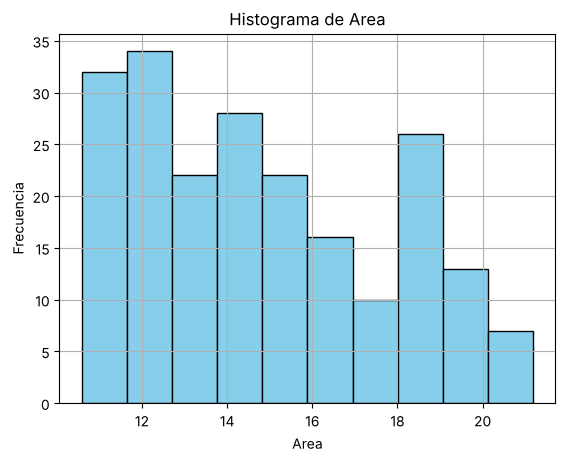

In [ ]:
#HISTOGRAMA DE AREA
plt.hist(seeds['Area'], bins=10, edgecolor='black', color='skyblue')
plt.title('Histograma de Area')
plt.xlabel('Area')
plt.ylabel('Frecuencia')
plt.grid()
plt.savefig('graficos/histograma_area.png')

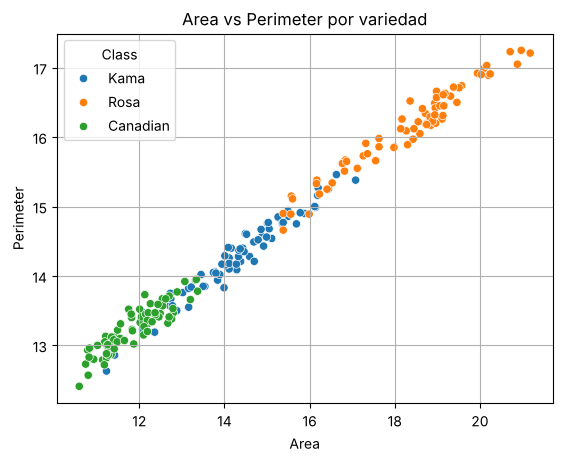

In [ ]:
#DISPERSION AREA VS PERIMETER DIFERENCIANDO LAS 3 VARIEDADES
nombres= {1:'Kama', 2:'Rosa', 3:'Canadian'}
sns.scatterplot(data=seeds, x='Area', y='Perimeter', hue=seeds['Class'].map(nombres))
plt.title('Area vs Perimeter por variedad')
plt.grid()
plt.savefig('graficos/dispersion_area_perimeter.png')

## 8. MODELOS DE CLASIFICACIÓN: K-VECINOS Y ÁRBOL DE DECISIÓN

In [ ]:
#MODELO 1: ARBOL DE DECISION
model= DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [ ]:
y_pred= model.predict(x_test)
print('PREDICCIONES DEL MODELO')
print(y_pred)
print('ETIQUETAS REALES')
print(y_test.values)

PREDICCIONES DEL MODELO
[3 3 2 1 1 3 1 3 1 3 2 3 1 2 1 2 3 1 3 2 2 1 3 1 2 3 1 2 1 3 3 3 1 1 2 2 3
 2 2 3 1 3]
ETIQUETAS REALES
[1 3 2 3 1 3 1 3 1 3 2 3 3 2 1 2 3 1 3 2 2 1 3 2 2 3 1 2 1 3 3 1 2 1 2 2 3
 2 2 3 3 3]


In [ ]:
print('Metricas del modelo (Arbol de Decision)')
acc_arbol= accuracy_score(y_test, y_pred)
print(acc_arbol)
print(classification_report(y_test, y_pred))

Metricas del modelo (Arbol de Decision)
0.8333333333333334
              precision    recall  f1-score   support

           1       0.64      0.82      0.72        11
           2       1.00      0.86      0.92        14
           3       0.88      0.82      0.85        17

    accuracy                           0.83        42
   macro avg       0.84      0.83      0.83        42
weighted avg       0.86      0.83      0.84        42



In [ ]:
#MODELO 2: K VECINOS CERCANOS
model2= KNeighborsClassifier()
model2.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[1,2,3]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
y_pred2= model2.predict(x_test)
print('PREDICCIONES DEL MODELO')
print(y_pred2)
print('ETIQUETAS REALES')
print(y_test.values)

PREDICCIONES DEL MODELO
[1 3 2 1 3 3 1 3 1 3 2 3 3 2 1 2 1 1 3 2 2 1 3 2 2 3 1 2 1 3 3 3 2 1 2 2 3
 2 2 3 1 3]
ETIQUETAS REALES
[1 3 2 3 1 3 1 3 1 3 2 3 3 2 1 2 3 1 3 2 2 1 3 2 2 3 1 2 1 3 3 1 2 1 2 2 3
 2 2 3 3 3]


In [ ]:
print('Metricas del modelo (K Vecinos)')
acc_knn= accuracy_score(y_test, y_pred2)
print(acc_knn)
print(classification_report(y_test, y_pred2))

Metricas del modelo (K Vecinos)
0.8809523809523809
              precision    recall  f1-score   support

           1       0.75      0.82      0.78        11
           2       1.00      1.00      1.00        14
           3       0.88      0.82      0.85        17

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42



Accuracy Arbol de Decision: 0.8333333333333334
Accuracy K Vecinos        : 0.8809523809523809


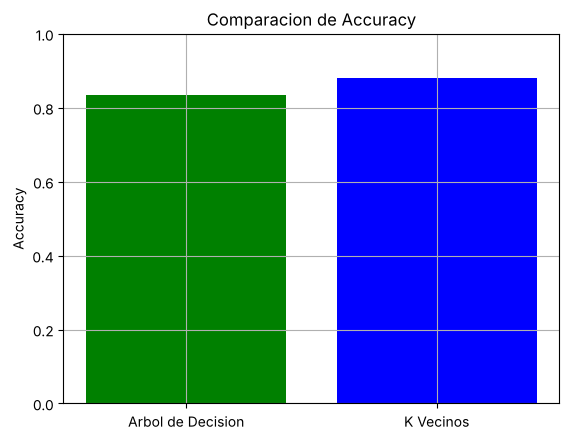

In [ ]:
#COMPARACION DE RESULTADOS
print('Accuracy Arbol de Decision:', acc_arbol)
print('Accuracy K Vecinos        :', acc_knn)
modelos= ['Arbol de Decision', 'K Vecinos']
valores= [acc_arbol, acc_knn]
plt.bar(modelos, valores, color=['g', 'b'])
plt.title('Comparacion de Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.grid()
plt.savefig('graficos/comparacion_modelos.png')